In [31]:
import datetime 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
# from githubanalysis.analysis.analyse_data import DataAnalyser


# dataanalyser = DataAnalyser(in_notebook=True, logger=None)
current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

2026-02-24


In [32]:
#"../../data/analysis_run_sample_45pc_2025-05-12/sample_PCA_eigenvalues_per_repo-individual__2025-05-13.csv"

# These files contain the labelled data, which was used 
# to generate the version with named RSE personas used below 
# in the PCA code

label_c0 = pd.read_csv("../../data/analysis_run_sample_45pc_cluster0_2025-05-13/sample_45pc_cluster0_personas_named_dataset_2025-05-30.csv", header=0, low_memory=False)
#pca_c0 = pd.read_csv("../../data/analysis_run_sample_45pc_cluster0_2025-05-13/sample_PCA_eigenvalues_per_repo-individual__2025-05-13.csv", header=0, low_memory=False)

label_c1 = pd.read_csv("../../data/analysis_run_sample_45pc_cluster1_2025-05-13/sample_45pc_cluster1_personas_named_dataset_2025-05-30.csv", header=0, low_memory=False)
#pca_c1 = pd.read_csv("../../data/analysis_run_sample_45pc_cluster1_2025-05-13/sample_PCA_eigenvalues_per_repo-individual__2025-05-13.csv", header=0, low_memory=False)

label_c2 = pd.read_csv("../../data/analysis_run_sample_45pc_cluster2_2025-05-13/sample_45pc_cluster2_personas_named_dataset_2025-05-30.csv", header=0, low_memory=False)
#pca_c2 = pd.read_csv("../../data/analysis_run_sample_45pc_cluster2_2025-05-13/sample_PCA_eigenvalues_per_repo-individual__2025-05-13.csv", header=0, low_memory=False)

2026-02-24
[None, 'grey']
Explained variability per principal component: [0.522901   0.18805082 0.12635007]
PCA 3D Plot saved out to file ../../images/sample_3D_PCA__2026-02-24.pdf.


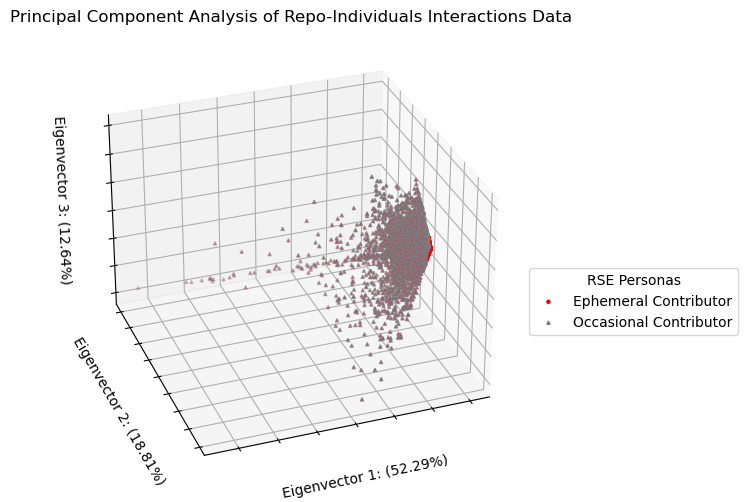

In [82]:
# CLUSTER 2: 

import datetime 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import seaborn as sns 
from sklearn.decomposition import PCA
from pathlib import Path

from utilities.rse_persona_info_utils import RSE_personas_info
from githubanalysis.analysis.analyse_data import DataAnalyser

rse_personas_info = RSE_personas_info()
dataanalyser = DataAnalyser(in_notebook=True, logger=None, dataset_name="set1-pca-cl1", exists_ok = True)
current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

from githubanalysis.visualization.plot_multidim_PCA import PlotPCA

# plotpca = PlotPCA(
#     in_notebook=True,
#     logger=dataanalyser.logger,
#     dataset_name = dataanalyser.dataset_name,
#     exists_ok = True,
# )

persona_data = pd.read_csv("../../data/analysis_run_sample_45pc_cluster2_2025-05-13/sample_45pc_cluster2_personas_named_dataset_2025-05-30.csv", header=0, low_memory=False)

persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("ephemeral_contributor", "Ephemeral Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("occasional_contributor", "Occasional Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("project_organiser", "Project Organiser")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("moderate_contributor", "Moderate Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("low-process_closer", "Low-Process Closer")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("low-coding_closer", "Low-Coding Closer")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("active_contributor", "Active Contributor")

cat_labels = [
    "Ephemeral Contributor",
    "Occasional Contributor",
    "Project Organiser",
    "Moderate Contributor",
    "Low-Process Closer",
    "Low-Coding Closer",
    "Active Contributor",
]


# drop misleading cluster_labels column which refers to the main groupings sub-cluster 
# e.g. 0, 1, 2 == medium, low, high interactivity). 
persona_data = persona_data.drop(columns="cluster_labels")

persona_data["RSE_persona_categorical"] = persona_data["RSE_persona"]
# change RSE Persona names from snake_case to Tidier Names
persona_data["RSE_persona_categorical"].replace(cat_labels, list(range(len(cat_labels))), inplace=True) 

# get the RSE persona category numbers set up as cluster labels
cluster_labels = persona_data['RSE_persona_categorical'] # imp for later param-setting!
cluster_names = persona_data["RSE_persona"]

# read in the clustering data (no categorical columns)
cluster_data_df = pd.read_csv("../../data/analysis_run_sample_45pc_cluster2_2025-05-13/sample_clustering_data_2025-05-13.csv", header=0, low_memory=False,)
clustering_data = cluster_data_df


( # get the parameters from the data for the relevant RSE personas info:
    persona_idx, 
    persona_col, 
    persona_mark, 
    persona_fill, 
    persona_edge, 
    persona_name,
) = rse_personas_info.get_params_based_on_cluster_info(cluster_labels=cluster_labels)

# run 3D PCA plotting with those correct persona-based plotting settings e.g. names, colours, marks, fill etc. 
pca3d(
    cluster_labels=cluster_labels,
    clustering_data=clustering_data,
    cluster_names = persona_name,
    colours=persona_col,
    marks= ['o', '^'],  
    fill_style =  ['full', 'full'], #persona_fill, 
    edge_col = ['red', 'grey'], #persona_edge
)


In [86]:
type(persona_edge)

list

2026-02-24
['black', 'grey', None]
Explained variability per principal component: [0.30514354 0.24929692 0.17758264]
PCA 3D Plot saved out to file ../../images/sample_3D_PCA__2026-02-24.pdf.


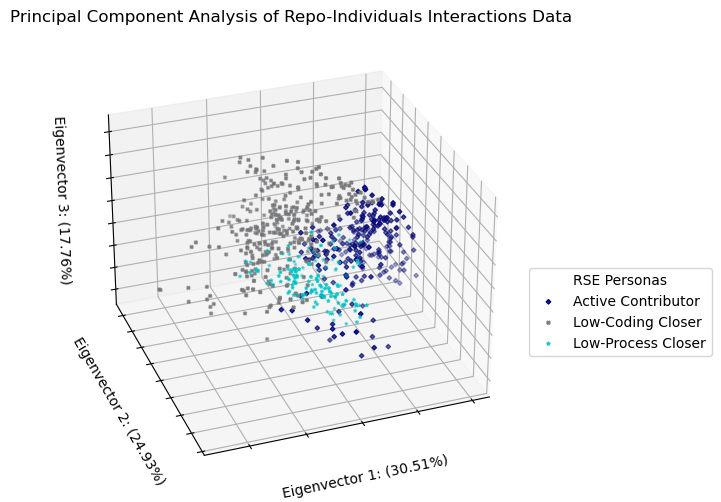

In [72]:
# CLUSTER 1: 

import datetime 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import seaborn as sns 
from sklearn.decomposition import PCA
from pathlib import Path

from utilities.rse_persona_info_utils import RSE_personas_info
from githubanalysis.analysis.analyse_data import DataAnalyser

rse_personas_info = RSE_personas_info()
dataanalyser = DataAnalyser(in_notebook=True, logger=None, dataset_name="set1-pca-cl1", exists_ok = True)
current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

from githubanalysis.visualization.plot_multidim_PCA import PlotPCA

# plotpca = PlotPCA(
#     in_notebook=True,
#     logger=dataanalyser.logger,
#     dataset_name = dataanalyser.dataset_name,
#     exists_ok = True,
# )

persona_data = pd.read_csv("../../data/analysis_run_sample_45pc_cluster1_2025-05-13/sample_45pc_cluster1_personas_named_dataset_2025-05-30.csv", header=0, low_memory=False)

persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("ephemeral_contributor", "Ephemeral Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("occasional_contributor", "Occasional Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("project_organiser", "Project Organiser")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("moderate_contributor", "Moderate Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("low-process_closer", "Low-Process Closer")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("low-coding_closer", "Low-Coding Closer")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("active_contributor", "Active Contributor")

cat_labels = [
    "Ephemeral Contributor",
    "Occasional Contributor",
    "Project Organiser",
    "Moderate Contributor",
    "Low-Process Closer",
    "Low-Coding Closer",
    "Active Contributor",
]


# drop misleading cluster_labels column which refers to the main groupings sub-cluster 
# e.g. 0, 1, 2 == medium, low, high interactivity). 
persona_data = persona_data.drop(columns="cluster_labels")

persona_data["RSE_persona_categorical"] = persona_data["RSE_persona"]
# change RSE Persona names from snake_case to Tidier Names
persona_data["RSE_persona_categorical"].replace(cat_labels, list(range(len(cat_labels))), inplace=True) 

# get the RSE persona category numbers set up as cluster labels
cluster_labels = persona_data['RSE_persona_categorical'] # imp for later param-setting!
cluster_names = persona_data["RSE_persona"]

# read in the clustering data (no categorical columns)
cluster_data_df = pd.read_csv("../../data/analysis_run_sample_45pc_cluster1_2025-05-13/sample_clustering_data_2025-05-13.csv", header=0, low_memory=False,)
clustering_data = cluster_data_df


( # get the parameters from the data for the relevant RSE personas info:
    persona_idx, 
    persona_col, 
    persona_mark, 
    persona_fill, 
    persona_edge, 
    persona_name,
) = rse_personas_info.get_params_based_on_cluster_info(cluster_labels=cluster_labels)

print(persona_edge)
# run 3D PCA plotting with those correct persona-based plotting settings e.g. names, colours, marks, fill etc. 
pca3d(
    cluster_labels=cluster_labels,
    clustering_data=clustering_data,
    cluster_names = persona_name,
    colours=persona_col,
    marks=['D', 'X', '*'],
    fill_style = ['full', 'full', 'full'], 
    edge_col = ['darkblue', 'grey', 'darkturquoise'] #persona_edge, 
)


2026-02-24
Explained variability per principal component: [0.42087225 0.18908615 0.15550259]
PCA 3D Plot saved out to file ../../images/sample_3D_PCA__2026-02-24.pdf.


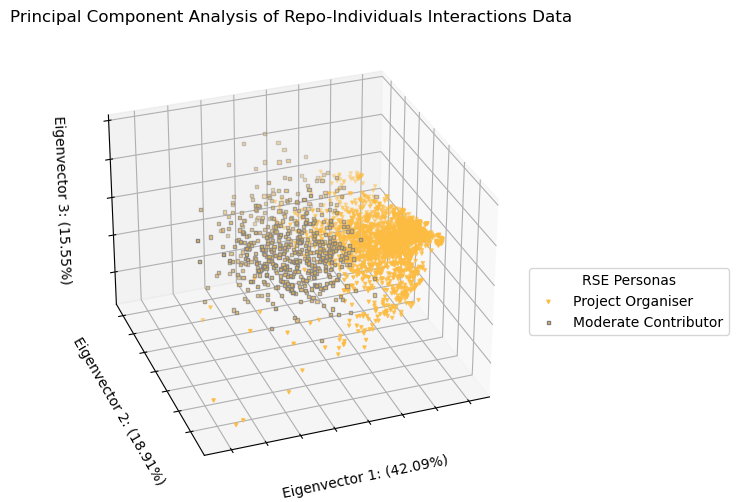

In [34]:
import datetime 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import seaborn as sns 
from sklearn.decomposition import PCA
from pathlib import Path

from utilities.rse_persona_info_utils import RSE_personas_info
from githubanalysis.analysis.analyse_data import DataAnalyser

rse_personas_info = RSE_personas_info()
dataanalyser = DataAnalyser(in_notebook=True, logger=None, dataset_name="set1-pca-lc0", exists_ok = True)
current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

from githubanalysis.visualization.plot_multidim_PCA import PlotPCA

cluster_data_df = pd.read_csv("../../data/analysis_run_sample_45pc_2025-05-12/sample_clustering_data_2025-05-12.csv", header=0, low_memory=False,)


# plotpca = PlotPCA(
#     in_notebook=True,
#     logger=dataanalyser.logger,
#     dataset_name = dataanalyser.dataset_name,
#     exists_ok = True,
# )

persona_data = pd.read_csv("../../data/analysis_run_sample_45pc_cluster0_2025-05-13/sample_45pc_cluster0_personas_named_dataset_2025-05-30.csv", header=0, low_memory=False)

persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("ephemeral_contributor", "Ephemeral Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("occasional_contributor", "Occasional Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("project_organiser", "Project Organiser")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("moderate_contributor", "Moderate Contributor")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("low-process_closer", "Low-Process Closer")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("low-coding_closer", "Low-Coding Closer")
persona_data["RSE_persona"] = persona_data[
    "RSE_persona"
].str.replace("active_contributor", "Active Contributor")

cat_labels = [
    "Ephemeral Contributor",
    "Occasional Contributor",
    "Project Organiser",
    "Moderate Contributor",
    "Low-Process Closer",
    "Low-Coding Closer",
    "Active Contributor",
]


# drop misleading cluster_labels column which refers to the main groupings sub-cluster 
# e.g. 0, 1, 2 == medium, low, high interactivity). 
persona_data = persona_data.drop(columns="cluster_labels")

persona_data["RSE_persona_categorical"] = persona_data["RSE_persona"]
# change RSE Persona names from snake_case to Tidier Names
persona_data["RSE_persona_categorical"].replace(cat_labels, list(range(len(cat_labels))), inplace=True) 

# get the RSE persona category numbers set up as cluster labels
cluster_labels = persona_data['RSE_persona_categorical'] # imp for later param-setting!
cluster_names = persona_data["RSE_persona"]

# read in the clustering data (no categorical columns)
cluster_data_df = pd.read_csv("../../data/analysis_run_sample_45pc_cluster0_2025-05-13/sample_clustering_data_2025-05-13.csv", header=0, low_memory=False,)
clustering_data = cluster_data_df


( # get the parameters from the data for the relevant RSE personas info:
    persona_idx, 
    persona_col, 
    persona_mark, 
    persona_fill, 
    persona_edge, 
    persona_name,
) = rse_personas_info.get_params_based_on_cluster_info(cluster_labels=cluster_labels)

# run 3D PCA plotting with those correct persona-based plotting settings e.g. names, colours, marks, fill etc. 
pca3d(
    cluster_labels=cluster_labels,
    clustering_data=clustering_data,
    cluster_names = persona_name,
    colours=persona_col,
    marks=persona_mark,
    fill_style = persona_fill, 
    edge_col = persona_edge,
)


In [33]:
def pca3d(
    #self,
    cluster_labels: np.ndarray,
    clustering_data: pd.DataFrame,
    cluster_names = cluster_names, 
    colours = persona_palette,
    marks = persona_mark,
    fill_style = persona_fill, 
    edge_col = persona_edge, 

    file_name: str = "sample_3D_PCA_",
    save_type: str = "pdf",  # one of: ['png', 'pdf', 'svg']
):
    

    clustering_data_labelled = pd.concat(
        [pd.DataFrame({"cluster_labels": cluster_labels}), clustering_data], axis=1
    )


    fig = plt.figure(1, figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)


    X_reduced = PCA(n_components=3).fit_transform(clustering_data_labelled)

    # this pulls data from the PCA.fit_transform() output X_reduced into N arrays, which is the N of personas:
    arrays = tuple( 
        np.array(
            [r for i, r in enumerate(X_reduced) if cluster_labels[i] == label]
        ) for label in cluster_labels.unique()
    )

    # get the appropriate data array, plotting mark and colour for each 'layer' of data (ie plotting in layers 1 persona at a time)
    mrks_used = []
    edges_used = []
    
    for arr, mark, col, fill, edge in zip(arrays, marks, colours, fill_style, edge_col): 
        mrks_used.append(mark)
        edges_used.append(edge)
        ax.scatter(
            arr[:, 0],
            arr[:, 1],
            arr[:, 2],
            c=[col]*len(arr),
            s=5,
            marker=MarkerStyle(mark, fillstyle=fill),
            edgecolor=edge,
        )
    

    PCA_3 = PCA(n_components=3)
    PCA_3_df = pd.DataFrame(
        data=PCA_3.fit_transform(clustering_data),
        columns=[
            "principal component 1",
            "principal component 2",
            "principal component 3",
        ],
    )

    print(
        f"{'Explained variability per principal component: {}'.format(PCA_3.explained_variance_ratio_)}"
    )

    eigenvec1 = (PCA_3.explained_variance_ratio_)[0] * 100
    eigenvec2 = (PCA_3.explained_variance_ratio_)[1] * 100
    eigenvec3 = (PCA_3.explained_variance_ratio_)[2] * 100
    ax.set(
        title="Principal Component Analysis of Repo-Individuals Interactions Data",
        xlabel=f"Eigenvector 1: ({round(eigenvec1, 2)}%)",
        ylabel=f"Eigenvector 2: ({round(eigenvec2, 2)}%)",
        zlabel=f"Eigenvector 3: ({round(eigenvec3, 2)}%)",
    )
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    
    # Add a legend
    legend1 = ax.legend(
        cluster_names,
        title="RSE Personas",
        bbox_to_anchor=(1, 0.5),
    )
    plot_file = Path(
        "../../images/",
        f"{file_name}_{current_date_info}.{save_type}",
    )
    plt.savefig(fname=plot_file, format=save_type, bbox_inches="tight")
    plt.close()
 
    print(f"PCA 3D Plot saved out to file {plot_file}.")
    return fig